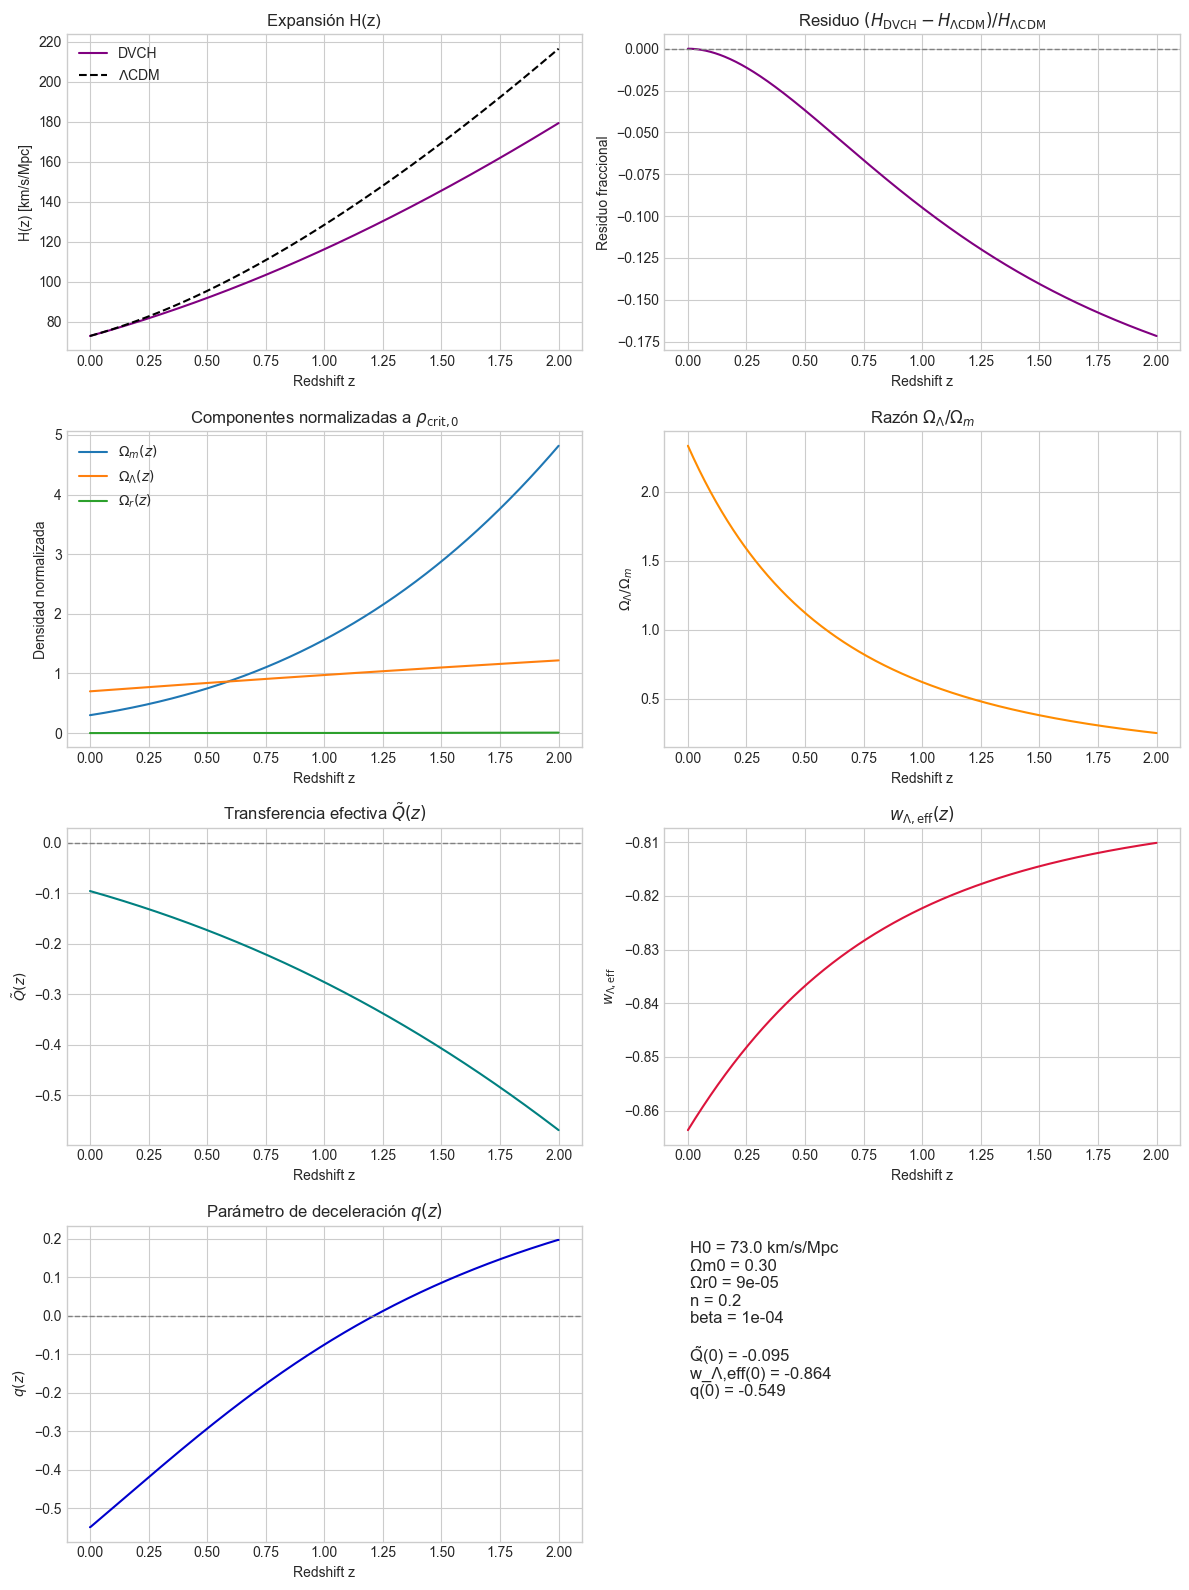

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

H0 = 73.0
Om0 = 0.30
Or0 = 9e-5
n = 0.2
beta = 1e-4
OL0 = 1.0 - Om0 - Or0


def rhs(z, y, n=n, beta=beta):
    Om, OL, Or = y

    Om = max(Om, 1e-15)
    OL = max(OL, 0.0)
    Or = max(Or, 0.0)

    E2 = max(Om + OL + Or, 1e-20)
    E = np.sqrt(E2)

    qtilde = -E * OL / (1.0 + n * OL / Om) * (
        n - (beta / (1.0 + beta * E2)) * ((4.0 * Or + 3.0 * Om) / 3.0)
    )

    dOL_dz = -3.0 * qtilde / (E * (1.0 + z))
    dOm_dz = 3.0 * (Om + qtilde / E) / (1.0 + z)
    dOr_dz = 4.0 * Or / (1.0 + z)

    return [dOm_dz, dOL_dz, dOr_dz]


z = np.linspace(0.0, 2.0, 500)

sol = solve_ivp(
    rhs,
    (0.0, 2.0),
    [Om0, OL0, Or0],
    t_eval=z,
    rtol=1e-9,
    atol=1e-12,
)

Om, OL, Or = sol.y
E = np.sqrt(np.maximum(Om + OL + Or, 1e-30))
H = H0 * E

E_lcdm = np.sqrt(Om0 * (1.0 + z) ** 3 + Or0 * (1.0 + z) ** 4 + OL0)
H_lcdm = H0 * E_lcdm

residuo = (H - H_lcdm) / H_lcdm
ratio = OL / Om

qtilde = -E * OL / (1.0 + n * OL / np.maximum(Om, 1e-15)) * (
    n - (beta / (1.0 + beta * E**2)) * ((4.0 * Or + 3.0 * Om) / 3.0)
)

w_eff = -1.0 - qtilde / (E * np.maximum(OL, 1e-15))
q = -1.0 + (1.0 + z) * np.gradient(E, z) / E

plt.style.use("seaborn-v0_8-whitegrid")
fig, axs = plt.subplots(4, 2, figsize=(12, 16))
axs = axs.flatten()

axs[0].plot(z, H, color="purple", label="DVCH")
axs[0].plot(z, H_lcdm, "k--", label=r"$\Lambda$CDM")
axs[0].set_title("Expansión H(z)")
axs[0].set_xlabel("Redshift z")
axs[0].set_ylabel("H(z) [km/s/Mpc]")
axs[0].legend()

axs[1].plot(z, residuo, color="purple")
axs[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axs[1].set_title(r"Residuo $(H_{\rm DVCH}-H_{\Lambda{\rm CDM}})/H_{\Lambda{\rm CDM}}$")
axs[1].set_xlabel("Redshift z")
axs[1].set_ylabel("Residuo fraccional")

axs[2].plot(z, Om, label=r"$\Omega_m(z)$")
axs[2].plot(z, OL, label=r"$\Omega_\Lambda(z)$")
axs[2].plot(z, Or, label=r"$\Omega_r(z)$")
axs[2].set_title(r"Componentes normalizadas a $\rho_{{\rm crit},0}$")
axs[2].set_xlabel("Redshift z")
axs[2].set_ylabel("Densidad normalizada")
axs[2].legend()

axs[3].plot(z, ratio, color="darkorange")
axs[3].set_title(r"Razón $\Omega_\Lambda/\Omega_m$")
axs[3].set_xlabel("Redshift z")
axs[3].set_ylabel(r"$\Omega_\Lambda/\Omega_m$")

axs[4].plot(z, qtilde, color="teal")
axs[4].axhline(0, color="gray", linestyle="--", linewidth=1)
axs[4].set_title(r"Transferencia efectiva $\tilde Q(z)$")
axs[4].set_xlabel("Redshift z")
axs[4].set_ylabel(r"$\tilde Q(z)$")

axs[5].plot(z, w_eff, color="crimson")
axs[5].set_title(r"$w_{\Lambda,\rm eff}(z)$")
axs[5].set_xlabel("Redshift z")
axs[5].set_ylabel(r"$w_{\Lambda,\rm eff}$")

axs[6].plot(z, q, color="mediumblue")
axs[6].axhline(0, color="gray", linestyle="--", linewidth=1)
axs[6].set_title(r"Parámetro de deceleración $q(z)$")
axs[6].set_xlabel("Redshift z")
axs[6].set_ylabel(r"$q(z)$")

axs[7].axis("off")
texto = (
    f"H0 = {H0} km/s/Mpc\n"
    f"Ωm0 = {Om0:.2f}\n"
    f"Ωr0 = {Or0:.0e}\n"
    f"n = {n}\n"
    f"beta = {beta:.0e}\n\n"
    f"Q̃(0) = {qtilde[0]:.3f}\n"
    f"w_Λ,eff(0) = {w_eff[0]:.3f}\n"
    f"q(0) = {q[0]:.3f}"
)
axs[7].text(0.05, 0.95, texto, va="top", fontsize=12)

plt.tight_layout()
plt.savefig("dvch_multiplot_z.png", dpi=300, bbox_inches="tight")
plt.show()